In [4]:
from IPython.display import Image, display

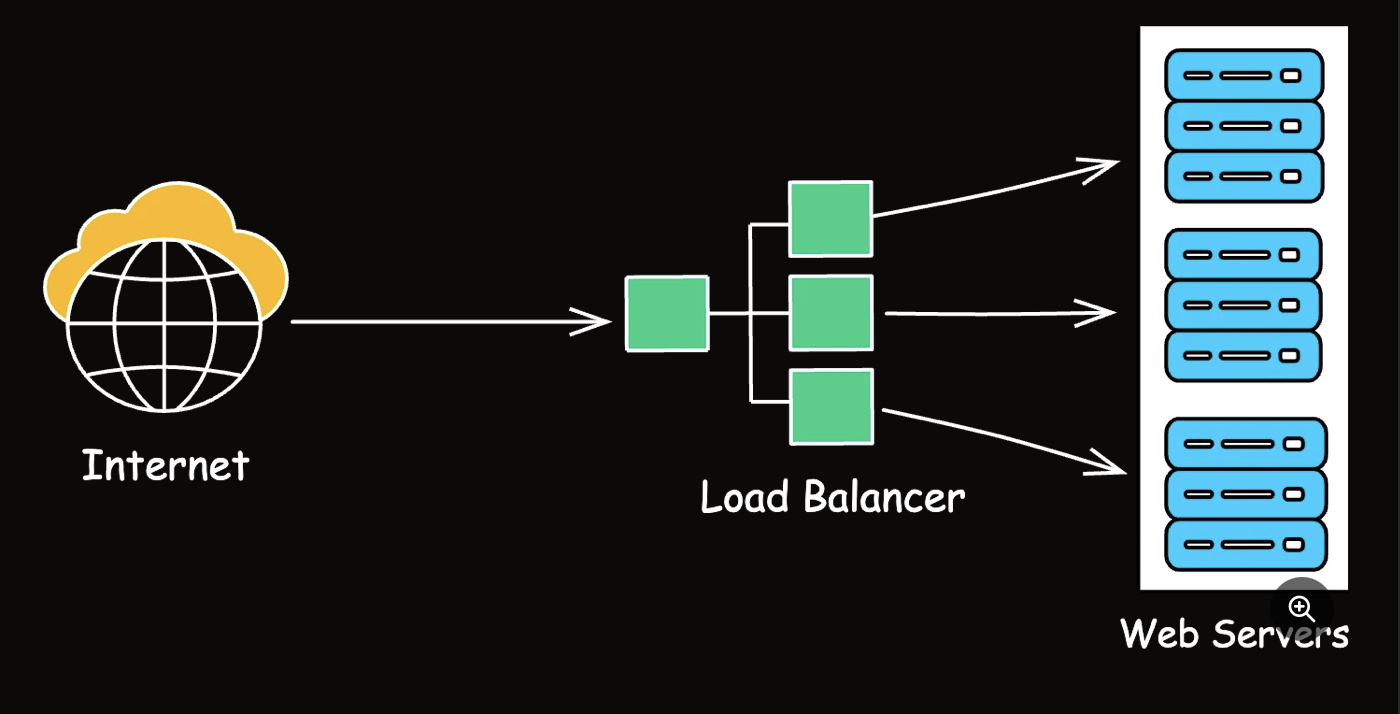

In [5]:
display(Image(filename='Utils/4.png'))

1. **Load Balancer is a system that spreads incoming network traffic across multiple backend servers (often called “worker nodes” or “application servers”).**

2. It ensures that no single server becomes a bottleneck due to an overload of requests. By distributing the load, applications can handle higher volumes of traffic and remain robust in the face of server failures.


## 1. Why Do We Need a Load Balancer?

1. **Scalability**: As traffic grows, you can add more servers behind the load balancer without 
redesigning your entire architecture.

2. **High Availability**: If one server goes offline or crashes, the load balancer automatically reroutes traffic to other healthy servers.

3. **Performance Optimization**: Balancing load prevents certain servers from overworking while others remain underutilized.

4. **Maintainability**: You can perform maintenance on individual servers without taking your entire application down.


## 2. Types of Load Balancers

Load balancers can be categorized in a few ways:

**Hardware vs. Software**

1. **Hardware Load Balancer**: Specialized physical devices often used in data centers (e.g., F5, Citrix ADC). They tend to be very powerful but can be expensive and less flexible.

2. **Software Load Balancer**: Runs on standard servers or virtual machines (e.g., Nginx, HAProxy, Envoy). These are often open-source or lower-cost solutions, highly configurable, and simpler to integrate with cloud providers.

**Layer 4 vs. Layer 7**

1. **Layer 4 (Transport Layer)**: Distributes traffic based on network information like IP address and port. It doesn’t inspect the application-layer data (HTTP, HTTPS headers, etc.).

2. **Layer 7 (Application Layer)**: Can make distribution decisions based on HTTP headers, cookies, URL path, etc. This is useful for advanced routing and application-aware features.

| Layer       | Looks at                                      | Can Route By                       | Typical Use                                         |
| ----------- | --------------------------------------------- | ---------------------------------- | --------------------------------------------------- |
| **Layer 4** | IP + Port                                     | Source/Dest IP, TCP/UDP Port       | Simple load balancing, low latency                  |
| **Layer 7** | Application data (HTTP headers, URL, cookies) | Path, Header, Method, Cookie, Host | Smart routing, A/B testing, content-aware balancing |


## 3. How Load Balancing Works

**Step 1: Traffic Reception**

All incoming requests arrive at the load balancer’s public IP or domain (e.g., www.myapp.com).

**Step 2: Decision Logic (Routing Algorithm)**

The load balancer decides which server should get the request. Common routing algorithms include:

1. Round Robin: Requests are distributed sequentially to each server in a loop.

2. Weighted Round Robin: Each server is assigned a weight (priority). Servers with higher weights receive proportionally more requests.

3. Least Connections: The request goes to the server with the fewest active connections.

4. IP Hash: The load balancer uses a hash of the client’s IP to always route them to the same server (useful for sticky sessions).

5. Random: Select a server randomly (sometimes used for quick prototypes or specialized cases).

**Step 3: Server Health Checks**

1. Load balancers usually have an internal mechanism to periodically check if servers are alive (e.g., by **sending a heartbeat request** like an HTTP GET /health).

2. If a server doesn’t respond within a certain threshold, it’s marked as unhealthy and no longer receives traffic.

3. When it recovers, the load balancer can automatically reintroduce it into the rotation.

**Step 4: Response Handling**

1. Once a request is forwarded to a healthy server, the server processes it and returns the response to the load balancer, which then returns it to the client.

2. Some load balancers forward responses directly, while others might modify headers or terminate SSL (HTTPS) connections for performance reasons.

Example : 

1. When you connect to a website like https://example.com, your browser encrypts everything using SSL/TLS (the lock symbol 🔐).

    So:
    The client (browser) encrypts the request.
    The server (backend) decrypts it.
    If you have 1,000,000 users, the backend has to decrypt 1,000,000 encrypted connections that’s very CPU heavy 😩

2. Now, when the load balancer performs SSL termination, it means:
       
       The load balancer decrypts the HTTPS request
       
       Sends it to the backend over plain HTTP (unencrypted)

That’s why it’s called termination (SSL TERMINATION) , the encrypted connection “ends” (terminates) at the load balancer.

Between the load balancer and backend, the traffic is unencrypted (HTTP).
So inside your internal network, if someone snoops, they could see the data.

## 4. Key Features

1. **SSL/TLS Termination**: Offloads cryptographic operations from the servers. The load balancer decrypts incoming SSL traffic and sends plain HTTP traffic to backend servers, reducing their CPU load.

2. **Sticky Sessions (Session Persistence)**: Ensures a client’s **subsequent requests are always routed to the same server**. This can be important for stateful applications (though it’s often better to design stateless services and store state externally, e.g., in a cache).

3. **Auto Scaling**: In cloud environments, you can integrate the load balancer with an auto-scaling group. As traffic increases, new servers spin up and automatically register with the load balancer.

4. **Caching and Compression**: Some load balancers (especially application-level) can **cache responses or compress them** to reduce bandwidth.

5. **Security Features**: Modern load balancers often support **Web Application Firewall (WAF) capabilities, DDoS protection**, and more.



## 5. Example Use Cases

1. **E-Commerce Website**: 

   1. During peak sale events (like Black Friday), a sudden traffic spike occurs. 
   2. A load balancer helps distribute that traffic evenly and ensures the system can scale horizontally by adding more servers.

2. **Video Streaming Platform**: 

   1. When thousands of users watch a popular live event, you need a load balancer to ensure seamless streaming.

3. **API Gateway**: 

    1. Modern microservices often **place a load balancer or reverse proxy in front of internal services to route API calls** based on route paths or hostnames.




## 6. Conclusion

1. A Load Balancer is often at the heart of any modern distributed system. 

2. It acts as traffic cop, ensuring that no single server is overwhelmed by requests and that your application remains available—even when individual servers fail.

3. By using load balancers effectively, you can:

    1. **Scale out** your infrastructure seamlessly.
    
    2. Enhance **availability and fault tolerance**.
    
    3. Improve performance by **offloading tasks like SSL termination and caching**.
    
    4. **Maintain your systems more easily**, taking servers offline without impacting the entire application.